In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns
import cv2
from PIL import Image, UnidentifiedImageError, ImageEnhance, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = False
from pathlib import Path
from collections import Counter, defaultdict
import hashlib
import shutil
from tqdm import tqdm
import random
import tensorflow as tf

from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras import layers, models
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
IMG_SIZE = (300, 300)
BATCH_SIZE = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "dataset_split/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "dataset_split/val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "dataset_split/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 1049 files belonging to 15 classes.
Found 218 files belonging to 15 classes.
Found 238 files belonging to 15 classes.


In [3]:

class_names = train_ds.class_names
num_classes = len(class_names)
print(class_names)
print(num_classes)

train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds   = val_ds.map(lambda x, y: (preprocess_input(x), y))
test_ds  = test_ds.map(lambda x, y: (preprocess_input(x), y))

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)

['Africanized Honey Bees (Killer Bees)', 'Aphids', 'Armyworms', 'Brown Marmorated Stink Bugs', 'Cabbage Loopers', 'Citrus Canker', 'Colorado Potato Beetles', 'Corn Borers', 'Corn Earworms', 'Fall Armyworms', 'Fruit Flies', 'Spider Mites', 'Thrips', 'Tomato Hornworms', 'Western Corn Rootworms']
15


In [4]:
for batch, _ in train_ds.take(1):
    print(tf.reduce_min(batch), tf.reduce_max(batch))

tf.Tensor(-123.68, shape=(), dtype=float32) tf.Tensor(151.061, shape=(), dtype=float32)


In [5]:

pretrained_model = tf.keras.applications.ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(300, 300, 3),
)

pretrained_model.trainable = True   # Fine-tune MobileNetV3_Large

# Freeze layer awal yang general
for layer in pretrained_model.layers[:-30]:
    layer.trainable = False

In [6]:
index = len(pretrained_model.layers) - 30
print("Index:", index)
print("Layer name:", pretrained_model.layers[index].name)

Index: 145
Layer name: conv5_block1_1_relu


In [7]:
model = models.Sequential([
    pretrained_model,
    layers.GlobalAveragePooling2D(),

    layers.Dense(512, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation="softmax")
])

In [8]:
pretrained_model.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 300, 300,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 306, 306,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 150, 150,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 150, 150,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 150, 150,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 152, 152,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 75, 75,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 75, 75,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 75, 75,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 75, 75,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 75, 75,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 75, 75,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 75, 75,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 75, 75,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 75, 75,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 75, 75,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 75, 75,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 14,450,176 (55.12 MB)

 Non-trainable params: 9,137,536 (34.86 MB)

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 10, 10, 2048)   │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,806,543 (94.63 MB)

 Trainable params: 15,667,215 (59.77 MB)

 Non-trainable params: 9,139,328 (34.86 MB)

In [10]:
train_labels_list = []

for _, labels in train_ds.unbatch():
    train_labels_list.append(int(labels.numpy()))

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(num_classes),
    y=train_labels_list
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(1.0758974358974358), 1: np.float64(1.2057471264367816), 2: np.float64(1.4569444444444444), 3: np.float64(0.8852320675105485), 4: np.float64(0.9712962962962963), 5: np.float64(0.9712962962962963), 6: np.float64(0.9201754385964912), 7: np.float64(0.8852320675105485), 8: np.float64(0.945045045045045), 9: np.float64(1.1655555555555555), 10: np.float64(0.9990476190476191), 11: np.float64(0.8633744855967078), 12: np.float64(0.9201754385964912), 13: np.float64(0.945045045045045), 14: np.float64(1.0758974358974358)}


In [11]:
model.compile(
    optimizer=tf.optimizers.AdamW(
        learning_rate=1e-4,
        weight_decay=5e-6
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

In [12]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    class_weight=class_weights,
    callbacks=[lr_scheduler, early_stop]
)

Epoch 1/40


33/33 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - accuracy: 0.0801 - loss: 3.8862 - val_accuracy: 0.1789 - val_loss: 2.5942 - learning_rate: 1.0000e-04
Epoch 2/40
33/33 ━━━━━━━━━━━━━━━━━━━━ 64s 2s/step - accuracy: 0.1706 - loss: 3.1694 - val_accuracy: 0.3761 - val_loss: 2.3119 - learning_rate: 1.0000e-04
Epoch 3/40
33/33 ━━━━━━━━━━━━━━━━━━━━ 63s 2s/step - accuracy: 0.2183 - loss: 2.8431 - val_accuracy: 0.5046 - val_loss: 1.9704 - learning_rate: 1.0000e-04
Epoch 4/40
33/33 ━━━━━━━━━━━━━━━━━━━━ 63s 2s/step - accuracy: 0.3108 - loss: 2.3751 - val_accuracy: 0.5229 - val_loss: 1.7434 - learning_rate: 1.0000e-04
Epoch 5/40
33/33 ━━━━━━━━━━━━━━━━━━━━ 63s 2s/step - accuracy: 0.3556 - loss: 2.1560 - val_accuracy: 0.5550 - val_loss: 1.5581 - learning_rate: 1.0000e-04
Epoch 6/40
33/33 ━━━━━━━━━━━━━━━━━━━━ 65s 2s/step - accuracy: 0.4071 - loss: 1.9457 - val_accuracy: 0.5826 - val_loss: 1.4262 - learning_rate: 1.0000e-04
Epoch 7/40
33/33 ━━━━━━━━━━━━━━━━━━━━ 64s 2s/step - accuracy: 0.4595 - loss: 1.7552 - v

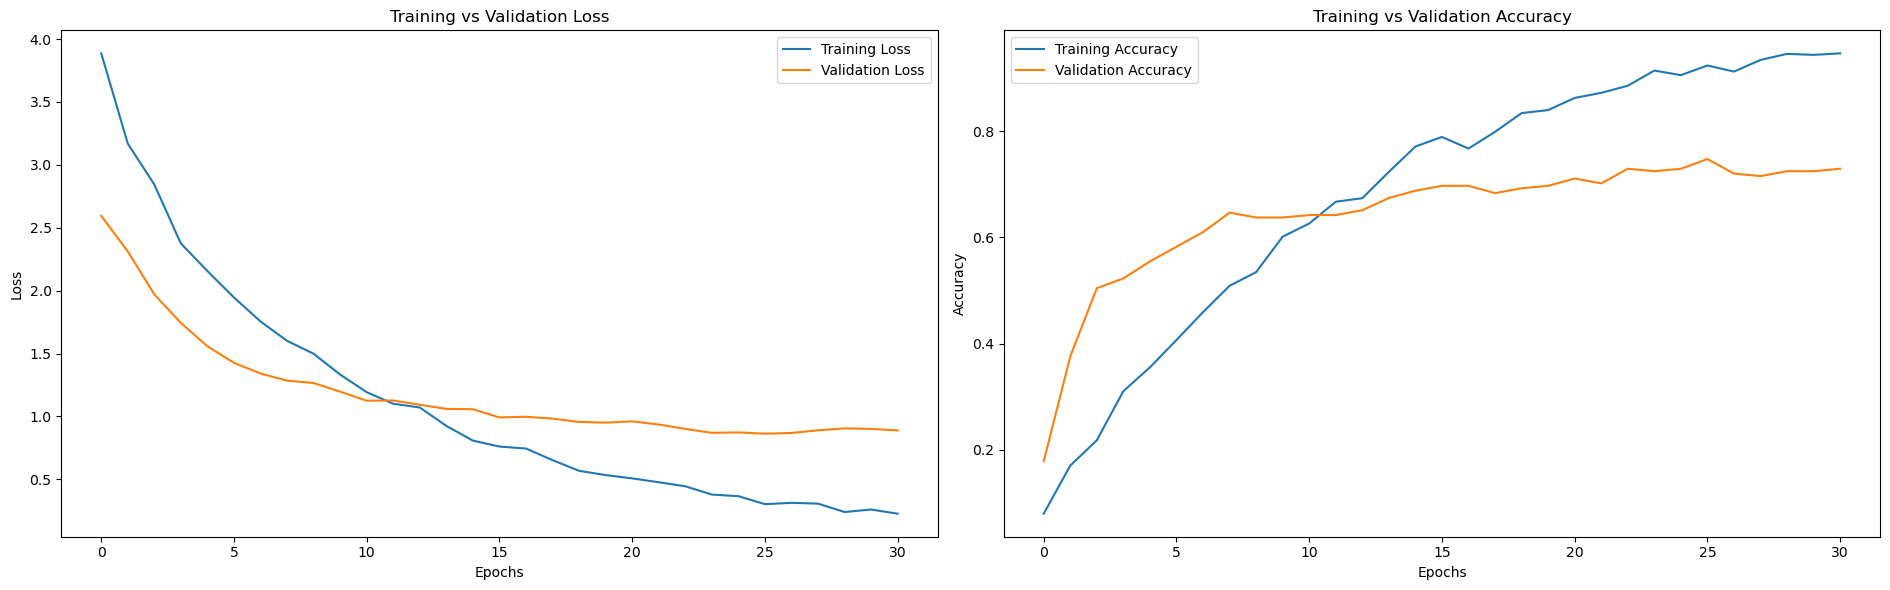

In [13]:
plt.figure(figsize=(19, 6))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [14]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)


y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.7605 - loss: 0.8277
Test Accuracy: 0.7605041861534119
Test Loss: 0.827700674533844
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [15]:
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

Classification Report:
                                      precision    recall  f1-score   support

Africanized Honey Bees (Killer Bees)       1.00      0.87      0.93        15
                              Aphids       0.83      0.77      0.80        13
                           Armyworms       0.62      0.73      0.67        11
         Brown Marmorated Stink Bugs       0.88      0.78      0.82        18
                     Cabbage Loopers       0.90      0.53      0.67        17
                       Citrus Canker       1.00      0.88      0.93        16
             Colorado Potato Beetles       1.00      0.94      0.97        17
                         Corn Borers       0.53      0.56      0.54        18
                       Corn Earworms       0.52      0.65      0.58        17
                      Fall Armyworms       0.42      0.57      0.48        14
                         Fruit Flies       0.93      0.93      0.93        15
                        Spider Mites    

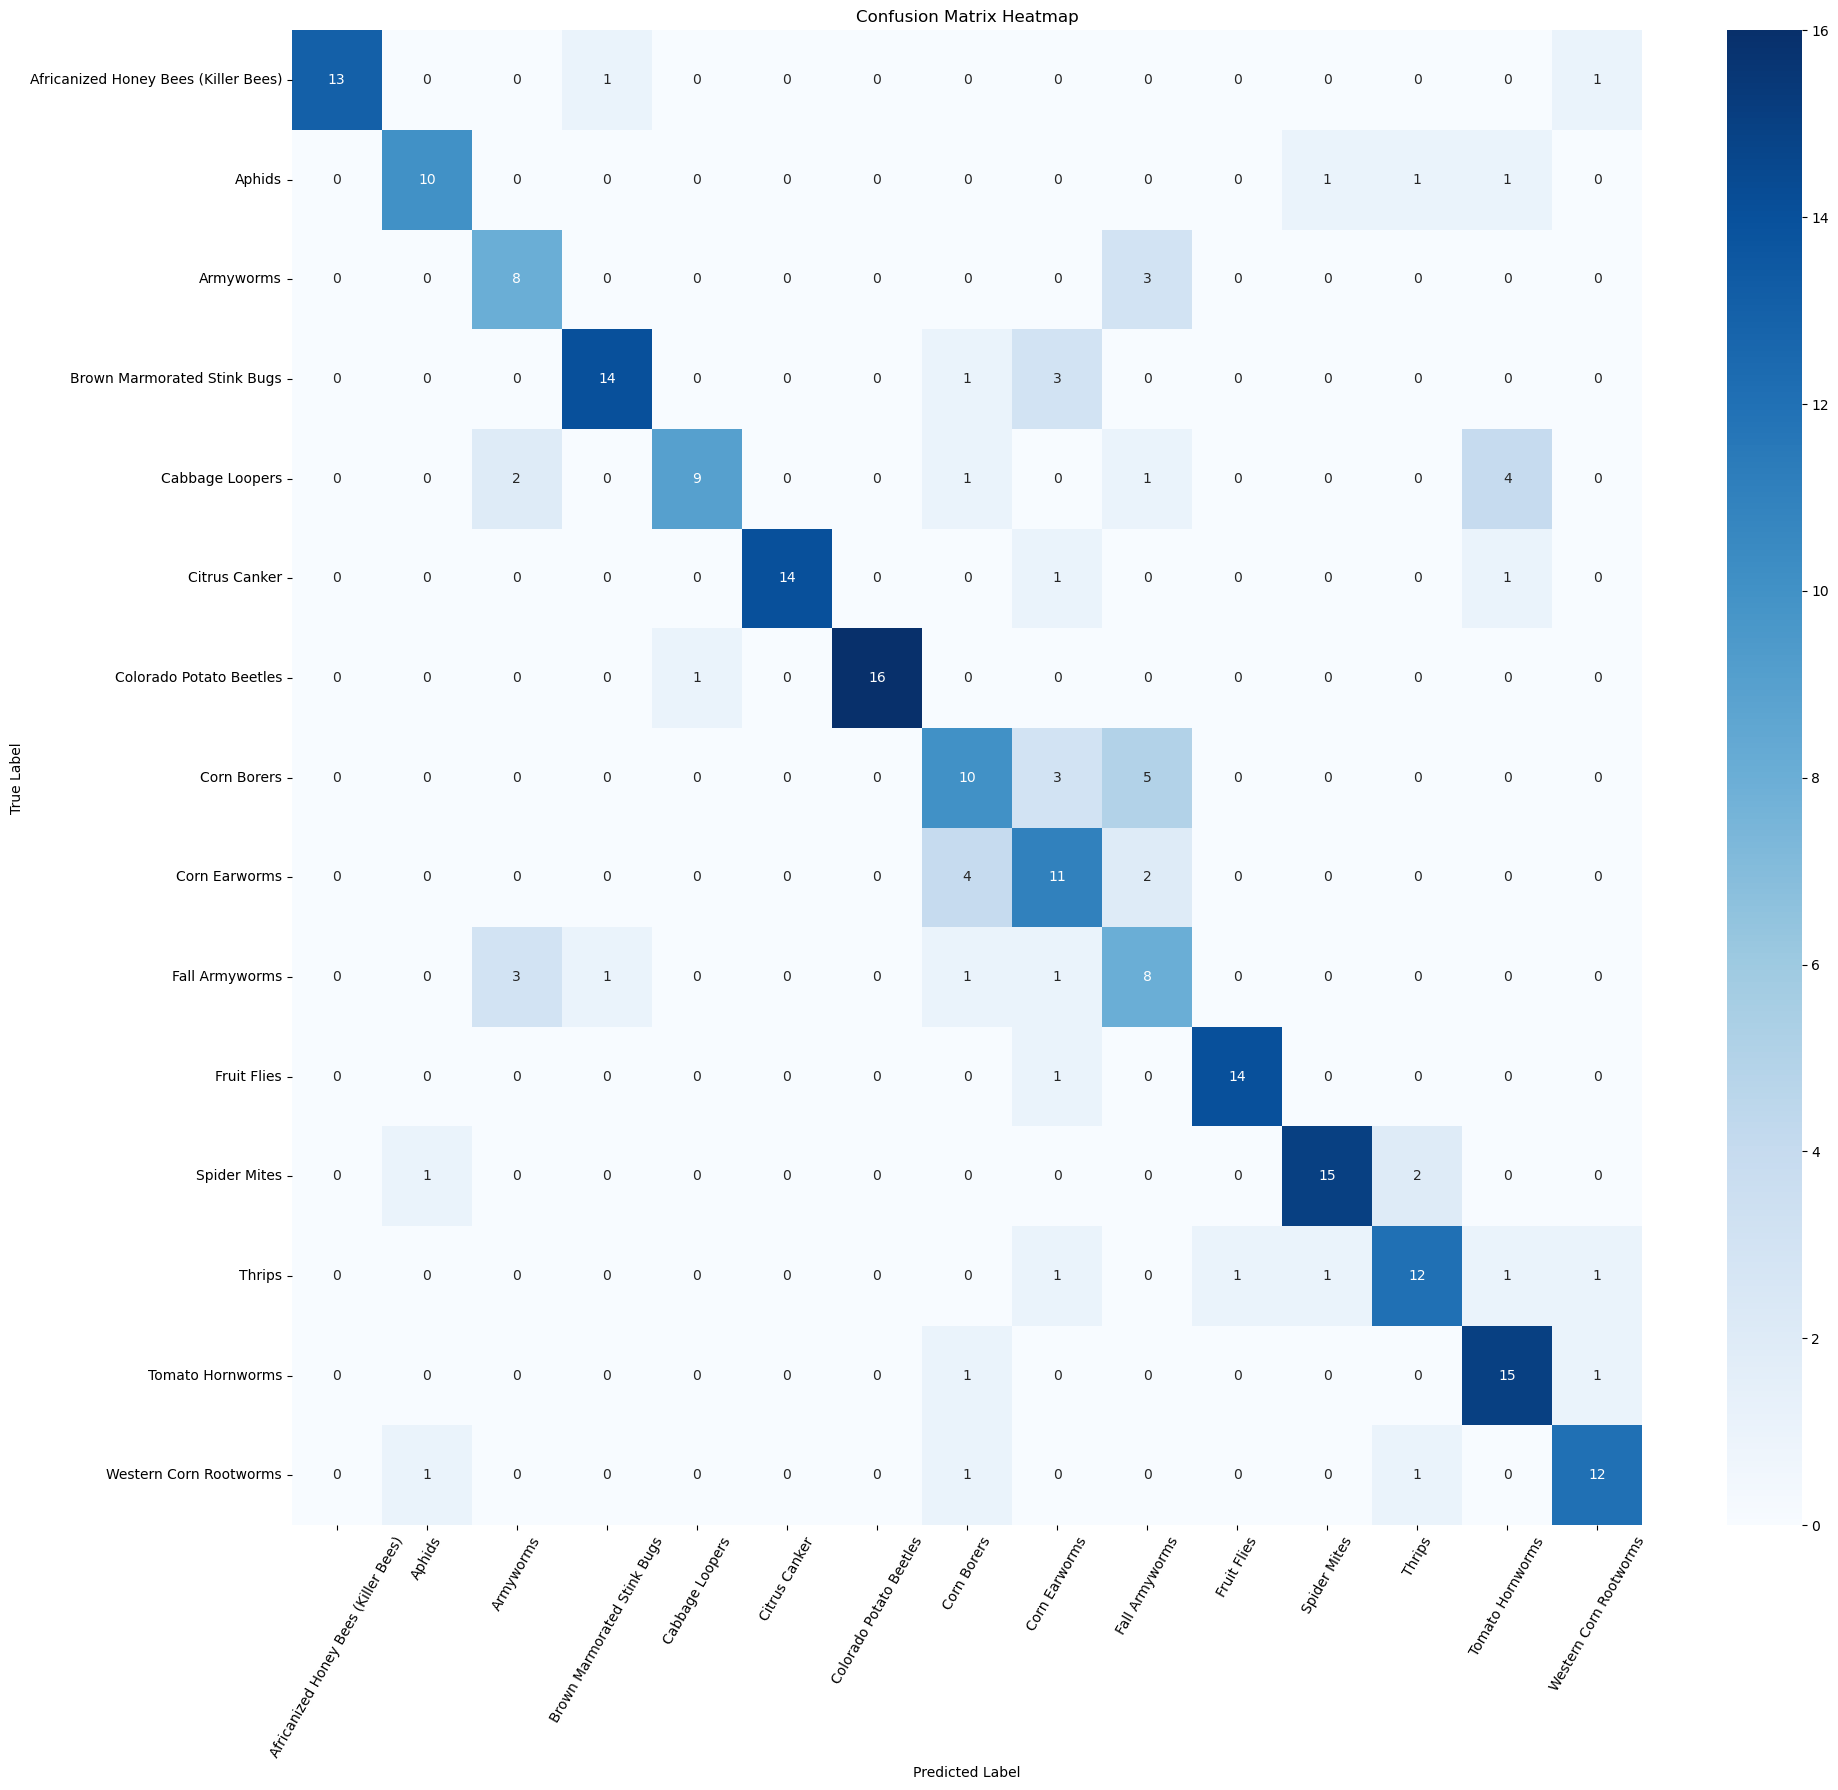

In [16]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(20, 18))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.xticks(rotation=60)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [17]:
def gradcam_heatmap(img_array, model, base_model, last_conv_name):
    last_conv_layer = base_model.get_layer(last_conv_name)

    x = base_model.output
    head_layers = model.layers[1:]

    for layer in head_layers:
        x = layer(x)

    grad_model = tf.keras.models.Model(
        inputs=base_model.input,
        outputs=[last_conv_layer.output, x]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        pred_output = predictions[:, pred_index]

    # Grads shape = (1, H, W, channels)
    grads = tape.gradient(pred_output, conv_outputs)

    # Compute channel importance
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]  # Drop batch dim

    # Weighted sum of channels
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    # Normalize
    heatmap = np.maximum(heatmap.numpy(), 0)
    denom = heatmap.max() if heatmap.max() != 0 else 1e-10
    heatmap /= denom

    return heatmap

In [19]:
for images, labels in test_ds.take(1):
    img = images[3].numpy()
    true_label = labels[0].numpy()
    break

img_array = np.expand_dims(img, axis=0)

base_model = model.layers[0]    # ResNet50
last_conv_name = "conv5_block3_3_conv"

heatmap = gradcam_heatmap(
    img_array,
    model=model,
    base_model=base_model,
    last_conv_name=last_conv_name
)

# Ubah ukuran heatmap ke ukuran asli gambar untuk overlay
heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
superimposed_img = heatmap_color * 0.4 + img.astype(np.uint8)

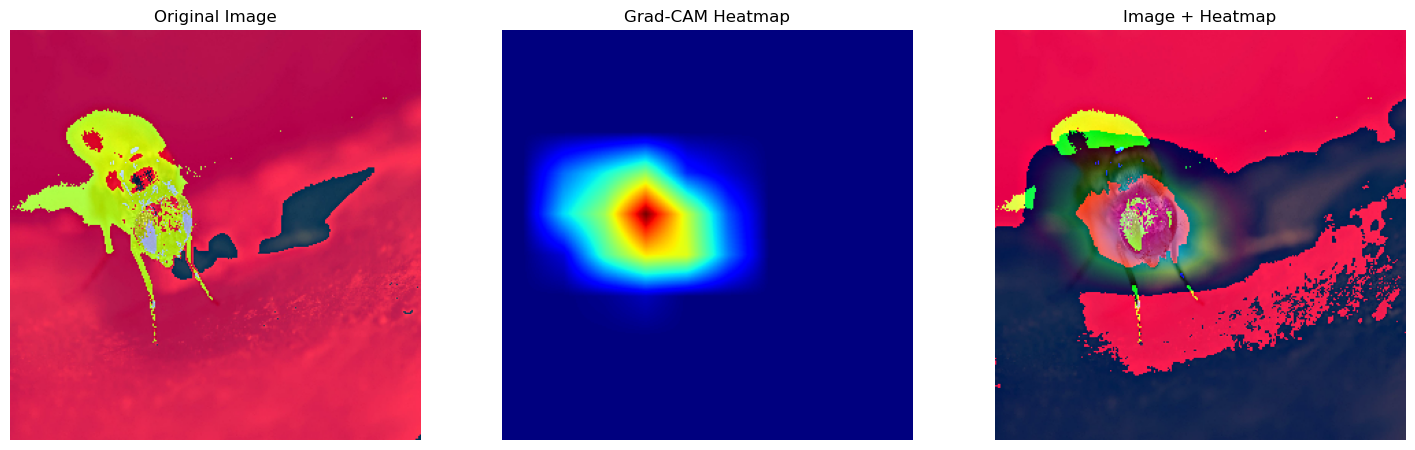

In [20]:
# Plotting
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(img.astype("uint8"))
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Grad-CAM Heatmap")
plt.imshow(heatmap_resized, cmap="jet")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Image + Heatmap")
plt.imshow(superimposed_img.astype("uint8"))
plt.axis("off")

plt.show()

In [22]:
model.save("ResNet50_model.h5")
model.save_weights("ResNet50_model_weights.weights.h5")